In [20]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math

In [21]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = 12  # 设置字体大小

In [22]:
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ["#89c8e8","#caa2f4","#1f78b4","#6a3d9a","#8acc72", "#ebd57c", "#ed4437", "#fc9a9a"]
colors = ["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"]
# from palettable.colorbrewer.qualitative import Set3_8
# colors = Set3_8.hex_colors
from palettable.cartocolors.qualitative import Safe_3
colors = Safe_3.hex_colors
# colors = ['#52d1dc', '#d4e09b', '#80917f', '#2b4162', '#d5896f', '#dea9a6', '#e7c8dd']
tag = ['Zip', 'Random', 'Cluster', 'Perplexity', 'Deita', 'SuperFiltering']
tag = ['0%', '25%', '50%', '75%']
markers = ['o', 's', 'D', '^', 'p', '*']
backbone_list = ['Llama-3-8B', 'Mistral-7B']

In [23]:
mt_bench = {
    'Llama-3-8B': [[7.25, 7.03, 6.75, 6.45]],
    'Mistral-7B': [[7.08, 6.5, 6.30, 6.03]],
    # 'Gemma2-9B': [[7.35, 7.27, 7.25, 7.18, 7.22, 6.97], [0.02, 0.026, 0.03, 0.029, 0.026, 0.042]],
}

compression_ratio = {
    'Llama-3-8B': [2.45, 2.64, 2.91, 3.17],
    'Mistral-7B': [2.45, 2.66, 2.92, 3.19],
    # 'Gemma2-9B': [2.45, 3.49, 3.55, 3.54, 4.42, 5.20],
}

first_epoch_loss = {
    'Llama-3-8B': [1.04, 0.8987, 0.9064, 0.8784, 0.7922, 0.6298],
    'Mistral-7B': [0.8515, 0.75, 0.73, 0.74, 0.62, 0.48],
    # 'Gemma2-9B': [0.9873, 0.8368, 0.8385, 0.8368, 0.76, 0.50],
}

In [24]:
def plot_with_curve(x, y, xlabel, ylabel, index=0):
    coefficients = np.polyfit(x, y, 2)
    p = np.poly1d(coefficients)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = p(x_fit)

    # Plot the original data points with different colors for each point
    for xi, yi, marker, point_tag in zip(x, y, markers, tag):
        plt.scatter(xi, yi, color=colors[index], marker=markers[index], s=42)
    # plt.plot(x, y, color=colors[index], marker=markers[index])
    # plt.scatter(x, y, color=colors[index], marker=markers[index], s=42, label=backbone_list[index])

    plt.plot(x_fit, y_fit, color=colors[index], linestyle='--')
    # plt.xticks(list(range(x)), labels=x)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)


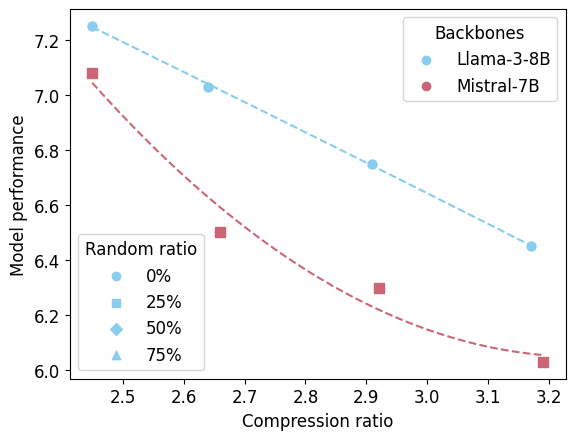

In [25]:

fig, ax1 = plt.subplots()
for idx, backbone in enumerate(backbone_list):
    plot_with_curve(
        compression_ratio[backbone],
        mt_bench[backbone][0],
        'Compression ratio',
        'Model performance',
        idx
    )
    # Display the plot

data_for_lengend1, data_for_lengend2 = [], []
for i, tag_ in enumerate(tag):
    rst = plt.scatter([], [], color=colors[0], marker=markers[i], label=f'{tag_}')
    data_for_lengend1.append(rst)
for i, backbone in enumerate(backbone_list):
    rst = plt.scatter([], [], color=colors[i], marker=markers[0], label=f'{backbone}')
    data_for_lengend2.append(rst)

lengend1 = plt.legend(data_for_lengend1, tag, title='Random ratio', loc='lower left')
plt.legend(data_for_lengend2, backbone_list, title='Backbones', loc='upper right')
# plt.plot([], [], label='Entropy-law curve', color=colors[0], linestyle='--')
plt.gca().add_artist(lengend1)
# plt.legend()

plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/zip-ratio.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()